# Water Potability Prediction Using Support Vector Machine (SVM)

# Problem Statement

Access to safe drinking water is essential for maintaining public health. Water quality is determined by several physical and chemical characteristics such as pH, hardness, dissolved solids, sulfate, conductivity, chloramines, organic carbon, trihalomethanes, and turbidity. Traditional laboratory testing methods are time-consuming and expensive.

The objective of this project is to develop a machine learning model that can accurately predict whether a water sample is potable (safe for drinking) or non-potable based on its water quality parameters. A Support Vector Machine (SVM) classifier is used to classify water samples and assist in faster and more reliable water quality assessment.

# Data Structure
 - The dataset consists of various physical and chemical properties of water samples. The objective is to analyze these water quality parameters and build a machine learning model to predict whether the water is safe for drinking.
 - Total Rows : 3276
 - Total Columns : 10
 - Independent Variables: 
pH,
Hardness,
Solids,
Chloramines,
Sulfate,
Conductivity,
Organic Carbon,
Trihalomethanes,
Turbidity,
Target Column,
Potability.
- Target Classes: 
1 – Potable (Safe for Drinking)
0 – Not Potable (Unsafe for Drinking)
- Problem Type: 
Binary Classification Problem
 - Machine Learning Model: 
Support Vector Machine (SVM)

# Library Import

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import plotly.express as pe
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import ADASYN


# Dataset Loaded

In [30]:
df=pd.read_csv("water_potability.csv")
df

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0
...,...,...,...,...,...,...,...,...,...,...
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1


# Data Understanding

In [31]:
df.head()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
0,NaN,204.890455,20791.318981,7.300212,368.516441,564.308654,10.379783,86.990970,2.963135,0
1,3.716080,129.422921,18630.057858,6.635246,NaN,592.885359,15.180013,56.329076,4.500656,0
2,8.099124,224.236259,19909.541732,9.275884,NaN,418.606213,16.868637,66.420093,3.055934,0
3,8.316766,214.373394,22018.417441,8.059332,356.886136,363.266516,18.436524,100.341674,4.628771,0
4,9.092223,181.101509,17978.986339,6.546600,310.135738,398.410813,11.558279,31.997993,4.075075,0


In [32]:
df.tail()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
3271,4.668102,193.681735,47580.991603,7.166639,359.948574,526.424171,13.894419,66.687695,4.435821,1
3272,7.808856,193.553212,17329.802160,8.061362,NaN,392.449580,19.903225,NaN,2.798243,1
3273,9.419510,175.762646,33155.578218,7.350233,NaN,432.044783,11.039070,69.845400,3.298875,1
3274,5.126763,230.603758,11983.869376,6.303357,NaN,402.883113,11.168946,77.488213,4.708658,1
3275,7.874671,195.102299,17404.177061,7.509306,NaN,327.459760,16.140368,78.698446,2.309149,1


In [33]:
print(f'Number of rows:{df.shape[0]}')
print(f'Number oF columns: {df.shape[1]}')

Number of rows:3276
Number oF columns: 10


In [34]:
df.describe()

,ph,Hardness,Solids,Chloramines,Sulfate,Conductivity,Organic_carbon,Trihalomethanes,Turbidity,Potability
count,2785.000000,3276.000000,3276.000000,3276.000000,2495.000000,3276.000000,3276.000000,3114.000000,3276.000000,3276.000000
mean,7.080795,196.369496,22014.092526,7.122277,333.775777,426.205111,14.284970,66.396293,3.966786,0.390110
std,1.594320,32.879761,8768.570828,1.583085,41.416840,80.824064,3.308162,16.175008,0.780382,0.487849
min,0.000000,47.432000,320.942611,0.352000,129.000000,181.483754,2.200000,0.738000,1.450000,0.000000
25%,6.093092,176.850538,15666.690297,6.127421,307.699498,365.734414,12.065801,55.844536,3.439711,0.000000
50%,7.036752,196.967627,20927.833607,7.130299,333.073546,421.884968,14.218338,66.622485,3.955028,0.000000
75%,8.062066,216.667456,27332.762127,8.114887,359.950170,481.792304,16.557652,77.337473,4.500320,1.000000
max,14.000000,323.124000,61227.196008,13.127000,481.030642,753.342620,28.300000,124.000000,6.739000,1.000000


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3276 entries, 0 to 3275
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ph               2785 non-null   float64
 1   Hardness         3276 non-null   float64
 2   Solids           3276 non-null   float64
 3   Chloramines      3276 non-null   float64
 4   Sulfate          2495 non-null   float64
 5   Conductivity     3276 non-null   float64
 6   Organic_carbon   3276 non-null   float64
 7   Trihalomethanes  3114 non-null   float64
 8   Turbidity        3276 non-null   float64
 9   Potability       3276 non-null   int64  
dtypes: float64(9), int64(1)
memory usage: 256.1 KB


In [36]:
df.dtypes

ph                 float64
Hardness           float64
Solids             float64
Chloramines        float64
Sulfate            float64
Conductivity       float64
Organic_carbon     float64
Trihalomethanes    float64
Turbidity          float64
Potability           int64
dtype: object

# Data Quality Check

In [37]:
df.duplicated().sum()

np.int64(0)

In [38]:
df.isna().sum()

ph                 491
Hardness             0
Solids               0
Chloramines          0
Sulfate            781
Conductivity         0
Organic_carbon       0
Trihalomethanes    162
Turbidity            0
Potability           0
dtype: int64

In [39]:
for i in df.columns:
    print(f'Missing values {i} in % = {(df[i].isna().sum()/3276)*100}')

Missing values ph in % = 14.987789987789988
Missing values Hardness in % = 0.0
Missing values Solids in % = 0.0
Missing values Chloramines in % = 0.0
Missing values Sulfate in % = 23.84004884004884
Missing values Conductivity in % = 0.0
Missing values Organic_carbon in % = 0.0
Missing values Trihalomethanes in % = 4.945054945054945
Missing values Turbidity in % = 0.0
Missing values Potability in % = 0.0


In [40]:
si=SimpleImputer(strategy='mean')
df[['ph','Sulfate','Trihalomethanes']]=si.fit_transform(df[['ph','Sulfate','Trihalomethanes']])


In [41]:
df.isna().sum()

ph                 0
Hardness           0
Solids             0
Chloramines        0
Sulfate            0
Conductivity       0
Organic_carbon     0
Trihalomethanes    0
Turbidity          0
Potability         0
dtype: int64

# Exploratory Data Analysis

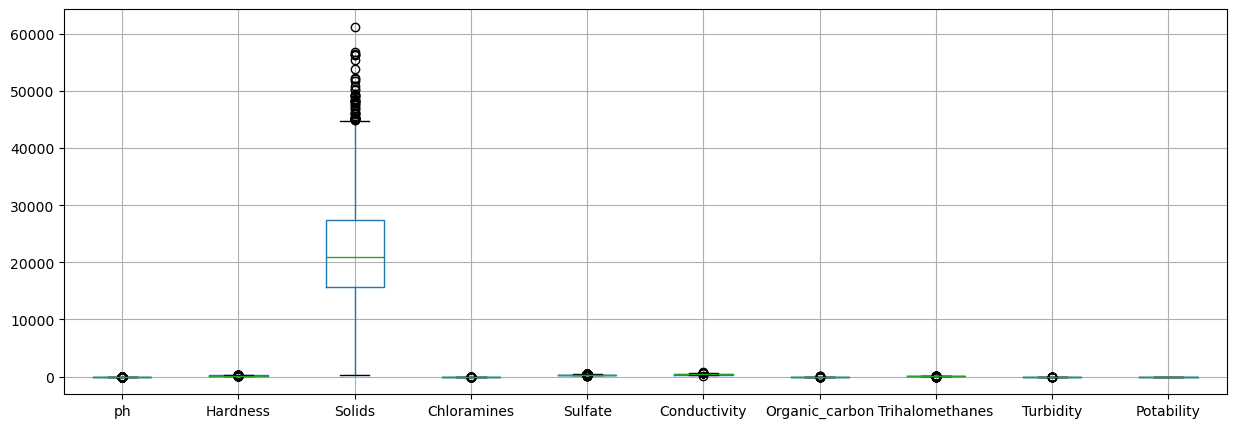

In [42]:
plt.figure(figsize=(15,5))
df.boxplot()
plt.show()

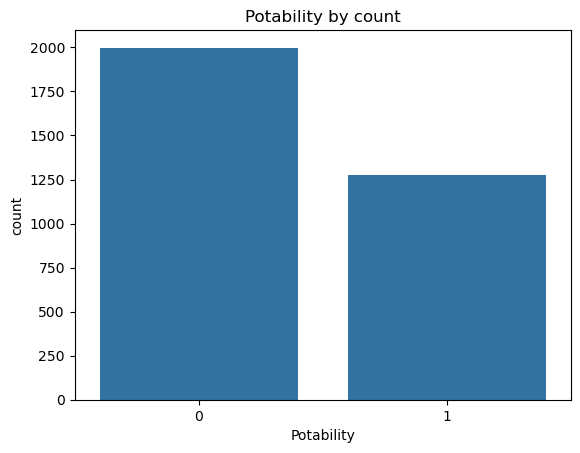

In [43]:
plt.title("Potability by count")
sns.countplot(x=df['Potability'])
plt.show()

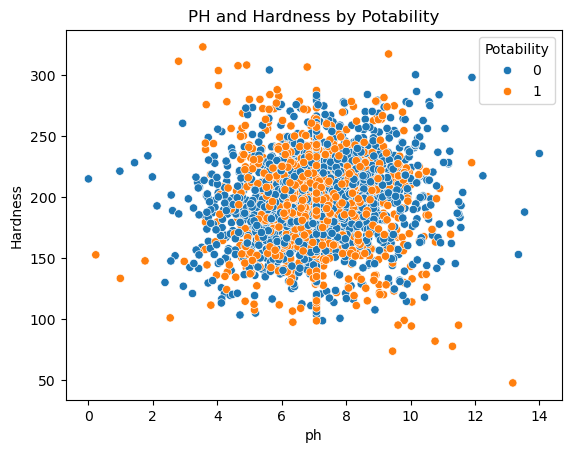

In [44]:
plt.title("PH and Hardness by Potability")
sns.scatterplot(x=df['ph'],y=df['Hardness'],hue=df['Potability'])
plt.show()

In [45]:
# 3D
pe.scatter_3d(data_frame=df,x='Sulfate',y='Conductivity',z='Organic_carbon',color='Potability')

# Defining X and y

In [46]:
X=df.drop(columns='Potability')
y=df['Potability']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# Feature selection

In [47]:
dtr=DecisionTreeClassifier()
dtr.fit(x_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [108]:
dtr_col=pd.Series(index=X.columns, data=dtr.feature_importances_)
dtr_imp_col=dtr_col.sort_values(ascending=False).head(6).index
dtr_imp_col

Index(['Sulfate', 'Chloramines', 'ph', 'Hardness', 'Solids', 'Organic_carbon'], dtype='object')

# Scaling

In [109]:
si=StandardScaler()
x_train_scaled=si.fit_transform(x_train[dtr_imp_col])
x_test_scaled=si.transform(x_test[dtr_imp_col])

# Sampling

In [110]:
df['Potability'].value_counts()

Potability
0    1998
1    1278
Name: count, dtype: int64

<Axes: xlabel='Potability', ylabel='count'>

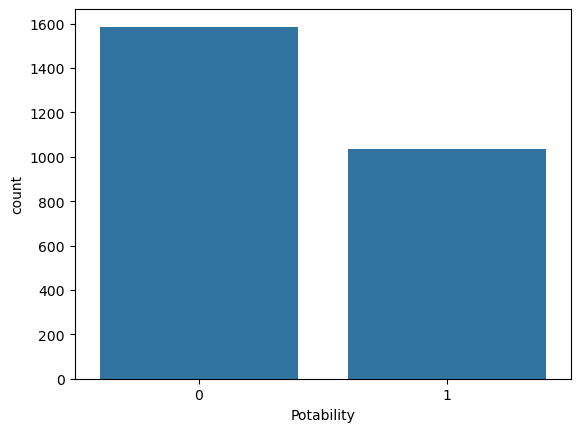

In [111]:
sns.countplot(x=y_train)

In [112]:
ada=ADASYN(random_state=42)
x_ada,y_ada=ada.fit_resample(x_train_scaled,y_train)

In [113]:
y_ada.value_counts()

Potability
0    1586
1    1582
Name: count, dtype: int64

# Model Traning

In [114]:
svc=SVC()
svc.fit(x_ada,y_ada)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


# Prediction

In [115]:
y_pred=svc.predict(x_test_scaled)
y_pred

array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0,
       0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1,
       1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1,
       1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0,

# Evaluation

In [116]:
print(classification_report(y_test,svc.predict(x_test_scaled)))
print(f'Traning Accuracy: {svc.score(x_train_scaled,y_train)}')
print(f'Testing Accuracy: {svc.score(x_test_scaled,y_test)}')

              precision    recall  f1-score   support

           0       0.76      0.58      0.66       412
           1       0.49      0.68      0.57       244

    accuracy                           0.62       656
   macro avg       0.62      0.63      0.61       656
weighted avg       0.66      0.62      0.63       656

Traning Accuracy: 0.6874045801526718
Testing Accuracy: 0.6189024390243902


# Hyperparameter Tuning

In [117]:
params={
    'kernel':['linear','poly','rbf','sigmoid'],
    'C':[0.1,1,10,100],
    'gamma':['scale','auto']
}
Grid=GridSearchCV(SVC(),params,scoring='accuracy',verbose=1)
Grid.fit(x_ada,y_ada)

print(Grid.best_params_)
print(Grid.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
{'C': 100, 'gamma': 'scale', 'kernel': 'rbf'}
0.6786605269584025


In [118]:
svc=SVC(C=100, gamma='scale', kernel='rbf')
svc.fit(x_ada,y_ada)
y_pred=svc.predict(x_test_scaled)
print(classification_report(y_test,y_pred))
print(f'Traning Accuracy: {svc.score(x_ada,y_ada)}')
print(f'Testing Accuracy: {svc.score(x_test_scaled,y_test)}')

              precision    recall  f1-score   support

           0       0.72      0.61      0.66       412
           1       0.48      0.60      0.53       244

    accuracy                           0.61       656
   macro avg       0.60      0.61      0.60       656
weighted avg       0.63      0.61      0.61       656

Traning Accuracy: 0.8175505050505051
Testing Accuracy: 0.6082317073170732


# Conclusion

This project successfully developed a Support Vector Machine (SVM) model to predict water potability based on various physical and chemical properties of water. The dataset was preprocessed by handling missing values, applying feature scaling, and addressing class imbalance using the ADASYN oversampling technique. Hyperparameter tuning was performed using GridSearchCV to improve model performance.

The trained model achieved a training accuracy of 81.76% and a testing accuracy of 60.82%. The classification report shows that the model performs better in identifying non-potable water (Class 0) than potable water (Class 1). This indicates that while the model has learned meaningful patterns from the training data, its performance on unseen data is moderate and there is scope for improvement.

Overall, the SVM model provides a useful baseline for water potability prediction. Future improvements such as advanced feature engineering, additional data preprocessing, better handling of class imbalance, and experimenting with other machine learning algorithms (e.g., Random Forest, XGBoost, or LightGBM) may further improve the prediction accuracy and overall model performance.